# 🧠 Model Training & Evaluation
**Project ResistAI**

In this notebook, we will train machine learning models to predict antimicrobial resistance based on our engineered features.

**Our Pipeline:**
1. **Load Data:** Import our cleaned `final_dataset.csv`.
2. **Split:** Divide the data into Training (80%) and Testing (20%) sets.
3. **Baseline Model:** Train a Random Forest classifier.
4. **Primary Model:** Train an optimized XGBoost classifier.
5. **Evaluation:** Compare Accuracy, AUC-ROC, and F1-Scores.
6. **Export:** Save the winning model for our Streamlit App.

In [2]:
import pandas as pd
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

# Set visual style for our confusion matrices
sns.set_theme(style="white")

In [3]:
# 1. Load the processed dataset
df = pd.read_csv("../data/processed/final_dataset.csv")

# These are the exact features we engineered in Notebook 02
feature_cols = [
    'species_enc', 'antibiotic_enc', 'isolation_source_enc', 
    'mic_value', 'multi_drug_count', 'gram_stain_enc'
]

X = df[feature_cols]
y = df['resistance']

print(f"Dataset loaded successfully. Total samples: {len(X)}")

Dataset loaded successfully. Total samples: 202608


In [4]:
# 2. Split the data
# Stratify=y ensures that both our training and testing sets have the exact same ratio of Resistant vs. Susceptible isolates.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size:  {X_test.shape[0]}")

Training set size: 162086
Testing set size:  40522


In [5]:
# 3. Train Baseline Model (Random Forest)
print("🌲 Training Random Forest...")
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
print("✅ Random Forest trained!")

# 4. Train Primary Model (XGBoost)
print("\n🚀 Training XGBoost...")
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)
print("✅ XGBoost trained!")

🌲 Training Random Forest...
✅ Random Forest trained!

🚀 Training XGBoost...
✅ XGBoost trained!



Random Forest Performance
Accuracy:  0.7570
AUC-ROC:   0.8314

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.72      0.75     20261
           1       0.74      0.79      0.76     20261

    accuracy                           0.76     40522
   macro avg       0.76      0.76      0.76     40522
weighted avg       0.76      0.76      0.76     40522


XGBoost Performance
Accuracy:  0.7500
AUC-ROC:   0.8276

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.81      0.76     20261
           1       0.78      0.69      0.73     20261

    accuracy                           0.75     40522
   macro avg       0.75      0.75      0.75     40522
weighted avg       0.75      0.75      0.75     40522



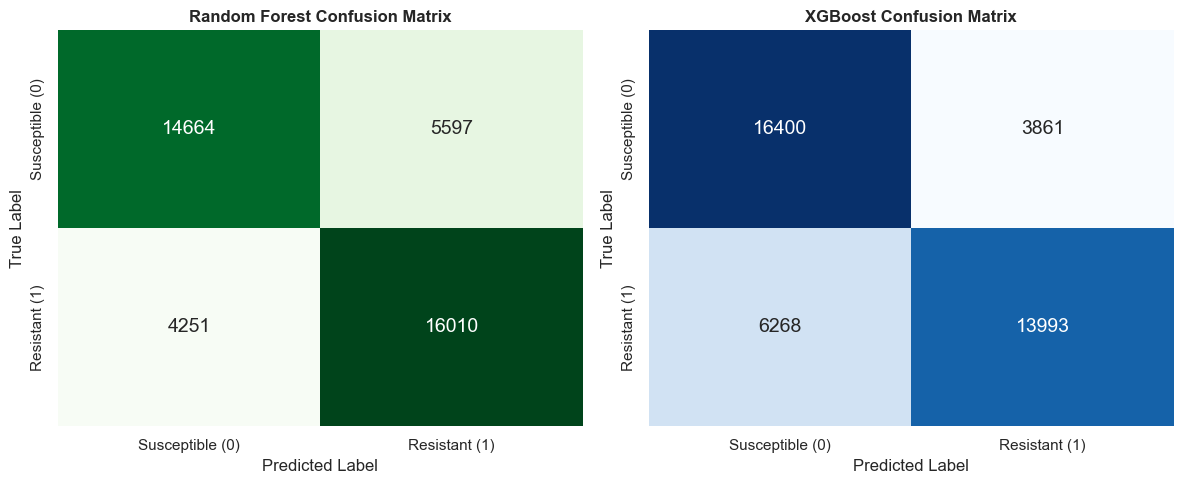

In [6]:
# 5. Evaluate the Models
models = [("Random Forest", rf_model), ("XGBoost", xgb_model)]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for idx, (name, model) in enumerate(models):
    # Get predictions
    preds = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    
    # Print text metrics
    print(f"\n{'='*30}\n{name} Performance\n{'='*30}")
    print(f"Accuracy:  {accuracy_score(y_test, preds):.4f}")
    print(f"AUC-ROC:   {roc_auc_score(y_test, proba):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, preds))
    
    # Plot Confusion Matrix
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues' if name=='XGBoost' else 'Greens', 
                ax=axes[idx], cbar=False, annot_kws={"size": 14})
    axes[idx].set_title(f"{name} Confusion Matrix", fontweight='bold')
    axes[idx].set_xlabel('Predicted Label')
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xticklabels(['Susceptible (0)', 'Resistant (1)'])
    axes[idx].set_yticklabels(['Susceptible (0)', 'Resistant (1)'])

plt.tight_layout()
plt.show()

In [7]:
# 6. Export the winning XGBoost model for our Streamlit UI
os.makedirs("../models", exist_ok=True)
joblib.dump(xgb_model, "../models/xgb_model.pkl")

print("🎉 XGBoost model saved successfully to models/xgb_model.pkl!")
print("The ML engine for ResistAI is complete.")

🎉 XGBoost model saved successfully to models/xgb_model.pkl!
The ML engine for ResistAI is complete.
